# 📊 Backtest Dashboard
All 11 charts rendered inline. Run **Run All** once — every chart appears as a cell output.
Navigate by scrolling, or collapse/expand individual cells.


In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
# %matplotlib widget   ← uncomment if you want interactive pan/zoom on every chart
# %matplotlib inline   ← static PNGs (default, fastest, works everywhere in VS Code)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# Inject the path so we can import our sibling modules
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
import signals as sig_mod
import portfolios as port_mod
import backtest as bt_mod

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
PALETTE = sns.color_palette("colorblind", 12)
_MC, _SC = {}, {}
def _mc(n):
    if n not in _MC: _MC[n] = PALETTE[len(_MC) % 12]
    return _MC[n]
def _sc(n):
    if n not in _SC: _SC[n] = PALETTE[len(_SC) % 12]
    return _SC[n]

print("Setup complete.")


Setup complete.


In [2]:
# ── Data  ─────────────────────────────────────────────────────────────────
# ┌─ REAL MODELS ─────────────────────────────────────────────────────────┐
# │ Uncomment the block below and comment out the DEMO block              │
# │                                                                       │
# │ from src.config import TEST_START, EXCLUDE                            │
# │ from src.model_io import load_sklearn_model, load_pytorch_model       │
# │ from src.models.neural import MLP                                     │
# │                                                                       │
# │ df       = pd.read_parquet("data/processed/clean_data.parquet")       │
# │ features = sorted(set(df.columns) - set(EXCLUDE))                    │
# │ test_df  = df[df["eom"] >= TEST_START].copy()                         │
# │ if "id" not in test_df.columns: test_df["id"] = test_df["gvkey"]     │
# │                                                                       │
# │ trained, pytorch_names = {}, set()                                    │
# │ for name in ["ridge","lasso","elasticnet","random_forest","xgboost"]: │
# │     if os.path.exists(f"models/{name}/model.pkl"):                    │
# │         trained[name] = load_sklearn_model(name)                     │
# │ if os.path.exists("models/mlp/model.pt"):                             │
# │     trained["mlp"] = load_pytorch_model(MLP, "mlp", len(features))   │
# │     pytorch_names.add("mlp")                                          │
# │                                                                       │
# │ pred_panels  = sig_mod.predict_all(trained, test_df, features,        │
# │                                    pytorch_names=pytorch_names)       │
# └───────────────────────────────────────────────────────────────────────┘

# ── DEMO (synthetic data — no WRDS / no GPU needed) ──────────────────────
rng = np.random.default_rng(42)
pred_panels = {}
for name, strength in [("mlp",0.013),("xgboost",0.011),
                        ("random_forest",0.009),("elasticnet",0.005),
                        ("lasso",0.004),("ridge",0.004)]:
    recs = []
    for d in pd.date_range("2016-01-31", periods=72, freq="ME"):
        n = 300; pred = rng.normal(size=n)
        shock = -0.10 if d.month==3 and d.year in (2018,2020) else 0.0
        ret = strength*pred + rng.normal(0,0.06,n) + shock
        recs.append(pd.DataFrame({"eom":d,"id":np.arange(n),
            "me":rng.lognormal(10,1,n),"ret_exc_lead1m":ret,"pred":pred}))
    pred_panels[name] = pd.concat(recs, ignore_index=True)

# ── Run pipeline ─────────────────────────────────────────────────────────
signal_table = sig_mod.evaluate_signals(pred_panels)
ports        = port_mod.build_all_portfolios(pred_panels, cost_bps=10.0)
comp         = bt_mod.generate_comparison_matrix(ports, signal_table=signal_table)
best, _, msg = bt_mod.final_verdict(comp)
best_key     = (best["model"], best["strategy"])

print(msg)
print("\nData ready — run the cells below to view charts.")


FINAL VERDICT  →  MLP  +  LS_decile_EW
  Composite score : 0.946 (rank-weighted across Sharpe, Sortino, drawdown, Calmar, Rank IC, turnover)
  Why            : best-in-class Sharpe (9.65); shallow drawdown (0.0%); strong Sortino (inf); Rank IC 0.202.
  Headline stats : Sharpe 9.65 | Sortino inf | AnnRet 49.6% | MaxDD 0.0% | Turnover 176%/mo

Data ready — run the cells below to view charts.


In [3]:
# ── Shared helpers ────────────────────────────────────────────────────────
def _cum(r):  return (1 + r).cumprod()
def _dd(r):   c = _cum(r); return (1 - c / c.cummax())

def _ric(panel, pred="pred", ret="ret_exc_lead1m", date="eom"):
    def _c(g):
        if g[pred].nunique() < 3 or g[ret].nunique() < 3: return np.nan
        return float(spearmanr(g[pred], g[ret])[0])
    return panel.groupby(date).apply(_c).dropna()

def _uniq(d, p): return list(dict.fromkeys(k[p] for k in d))


## ① Signal Quality

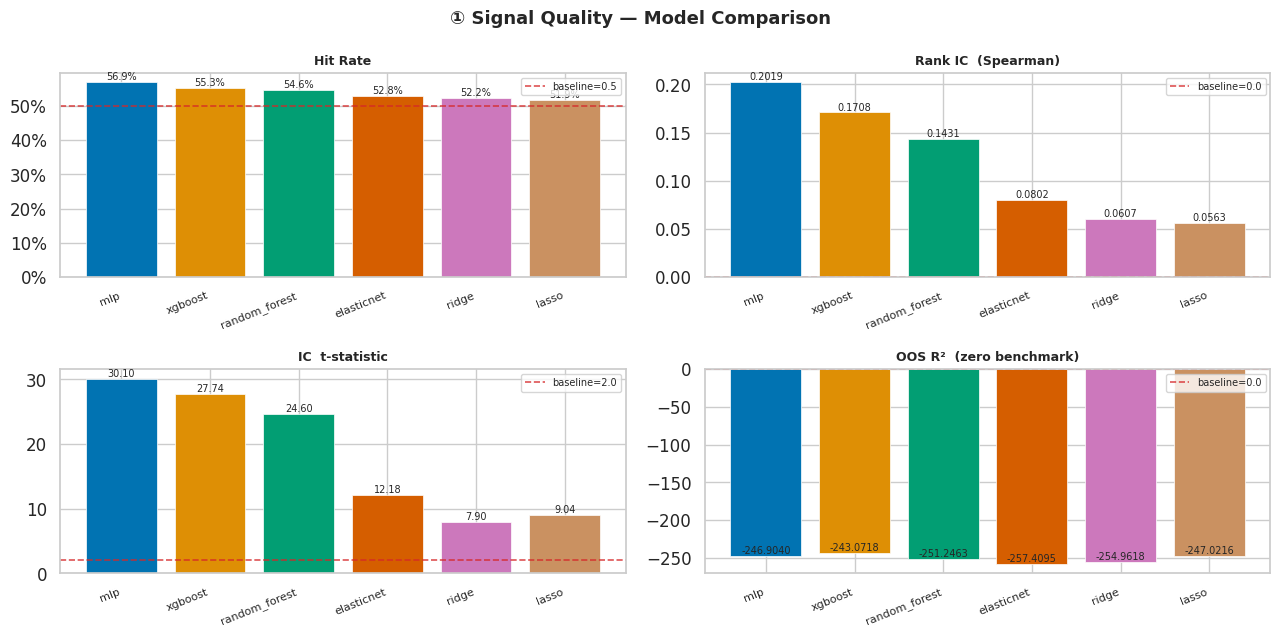

In [4]:
df = signal_table.sort_values("ric_mean", ascending=False)
models = df.index.tolist(); x = np.arange(len(models))
colors = [_mc(m) for m in models]

panels = [
    ("hit_rate",  "Hit Rate",                0.50, True,  "{:.1%}"),
    ("ric_mean",  "Rank IC  (Spearman)",      0.00, False, "{:.4f}"),
    ("ic_t_stat", "IC  t-statistic",          2.00, False, "{:.2f}"),
    ("oos_r2",    "OOS R²  (zero benchmark)", 0.00, False, "{:.4f}"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
fig.suptitle("① Signal Quality — Model Comparison", fontsize=13, fontweight="bold")
for (col, title, hl, pct, fmt), ax in zip(panels, axes.ravel()):
    if col not in df: ax.set_visible(False); continue
    vals = df[col].values.astype(float)
    bars = ax.bar(x, vals, color=colors, edgecolor="white", lw=0.5)
    ax.axhline(hl, color="#d62728", lw=1.2, ls="--", alpha=0.8, label=f"baseline={hl}")
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=22, ha="right", fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=9)
    if pct: ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001*(abs(v)+1e-9),
                    fmt.format(v), ha="center", va="bottom", fontsize=7)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


## ② Monthly Rank IC Time Series

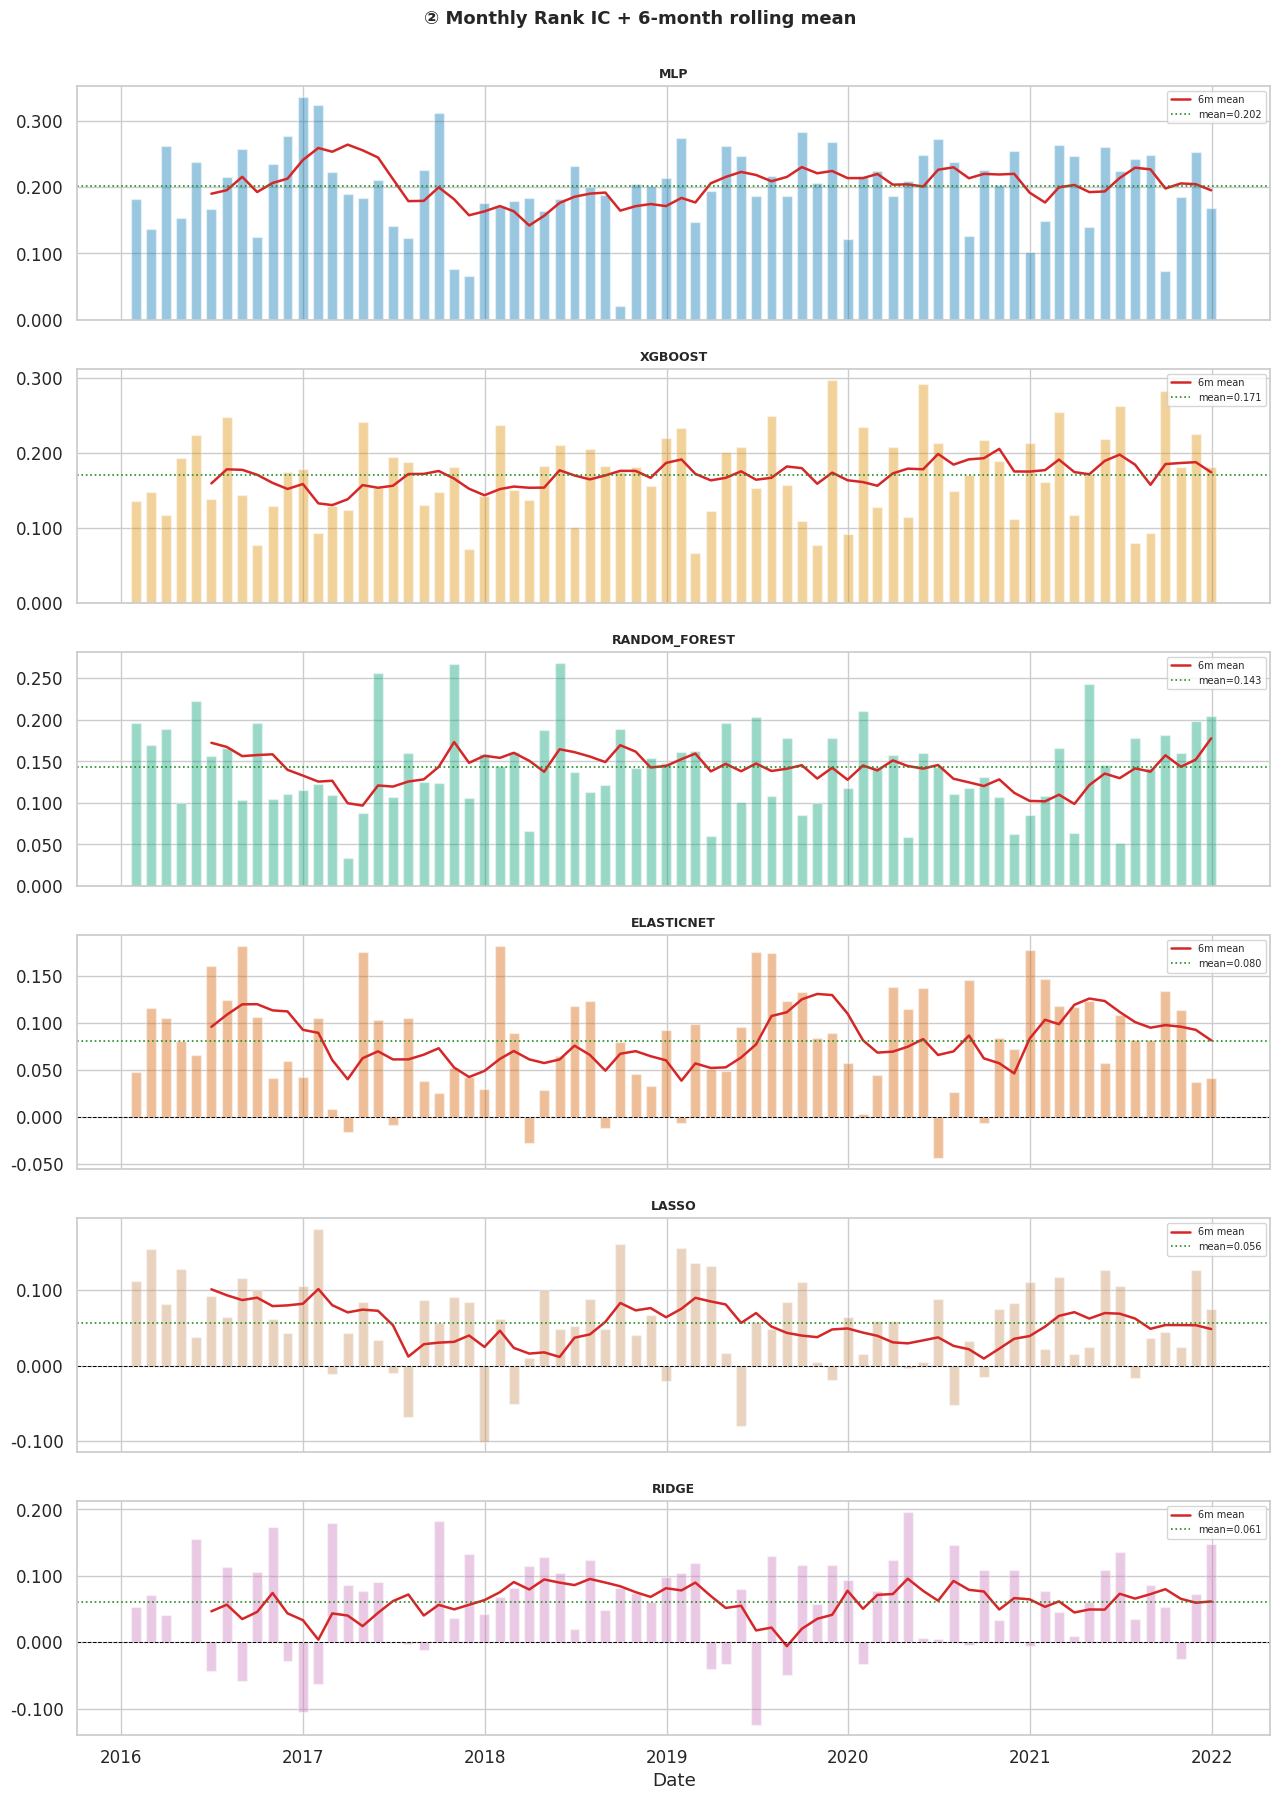

In [5]:
items = list(pred_panels.items()); n = len(items)
fig, axes = plt.subplots(n, 1, figsize=(13, 3*n), sharex=True)
if n == 1: axes = [axes]
fig.suptitle("② Monthly Rank IC + 6-month rolling mean",
             fontsize=13, fontweight="bold", y=1.0)
for ax, (name, panel) in zip(axes, items):
    r = _ric(panel); roll = r.rolling(6).mean()
    ax.bar(r.index, r.values, color=_mc(name), alpha=0.4, width=20)
    ax.plot(roll.index, roll.values, color="#d62728", lw=1.8, label="6m mean")
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.axhline(r.mean(), color="forestgreen", lw=1.2, ls=":", label=f"mean={r.mean():.3f}")
    ax.set_title(name.upper(), fontweight="bold", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()


## ③ Cumulative Returns

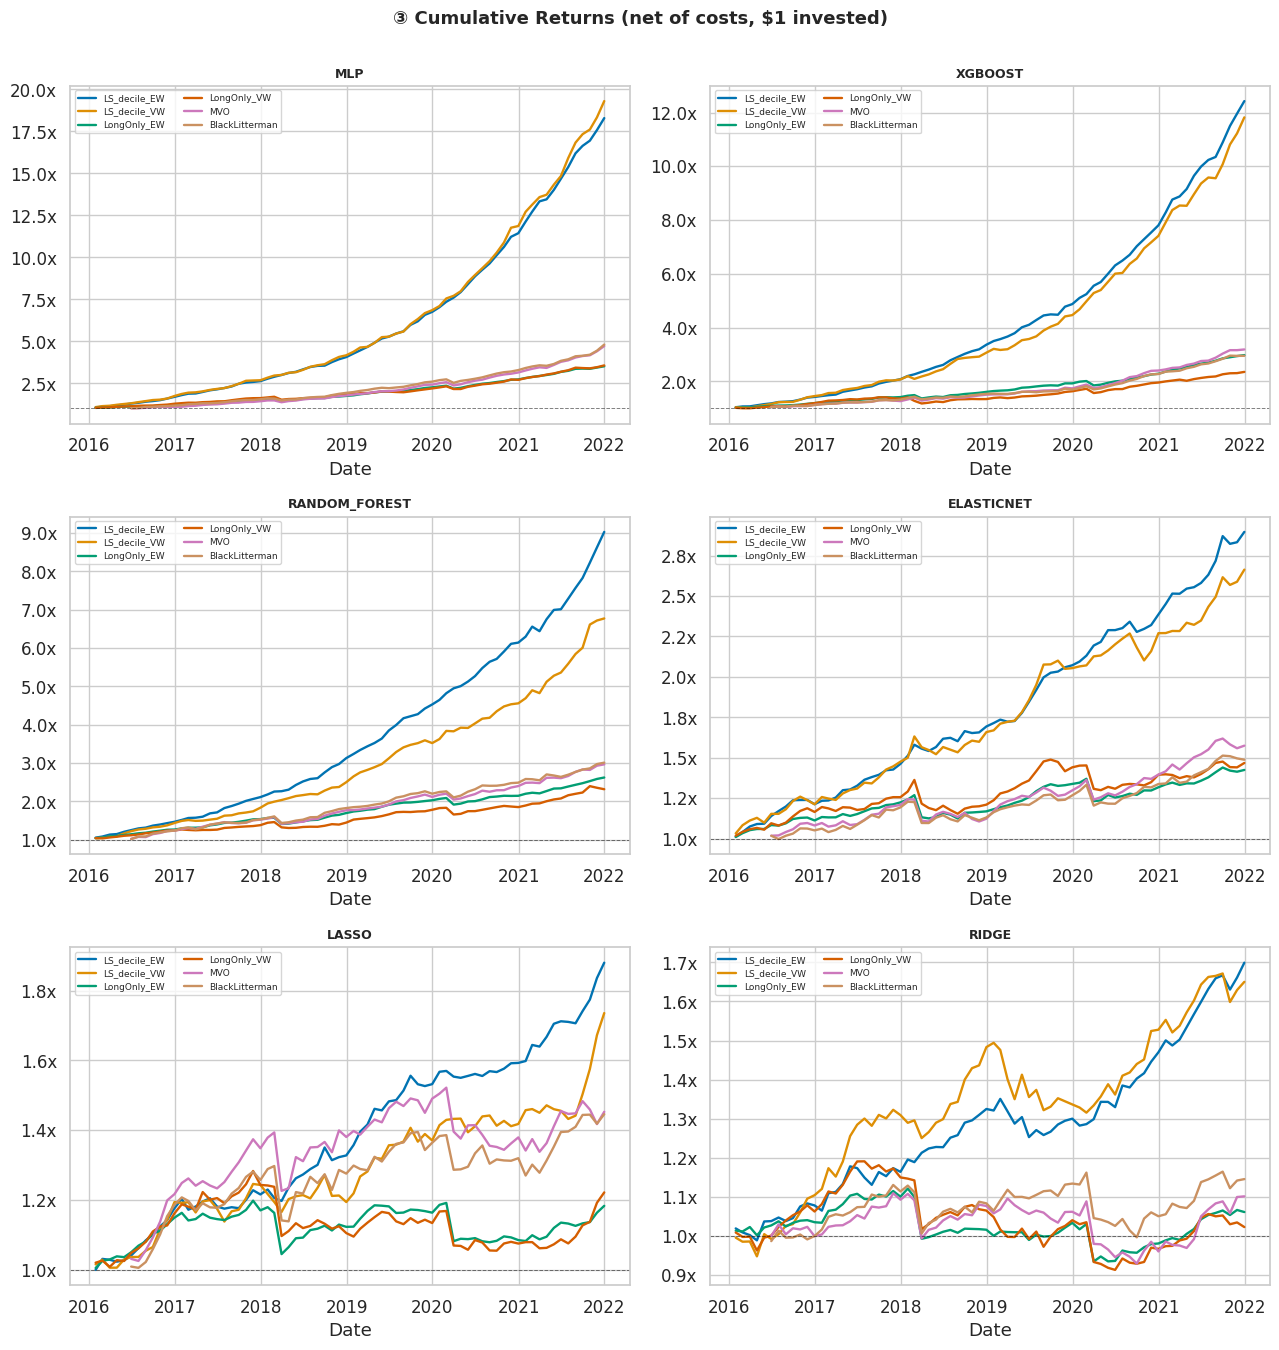

In [6]:
models = _uniq(ports, 0); n = len(models)
ncols = min(2,n); nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5*nrows))
axes = np.array(axes).ravel()
fig.suptitle("③ Cumulative Returns (net of costs, $1 invested)",
             fontsize=13, fontweight="bold", y=1.0)
for ax, m in zip(axes, models):
    for (mod,s), res in ports.items():
        if mod != m: continue
        c = _cum(res["ret_net"].dropna())
        ax.plot(c.index, c.values, lw=1.7, color=_sc(s), label=s)
    ax.axhline(1, color="black", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(m.upper(), fontweight="bold", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1fx"))
    ax.legend(fontsize=6.5, ncol=2, loc="upper left")
    ax.set_xlabel("Date")
for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()


## ④ Drawdown Charts

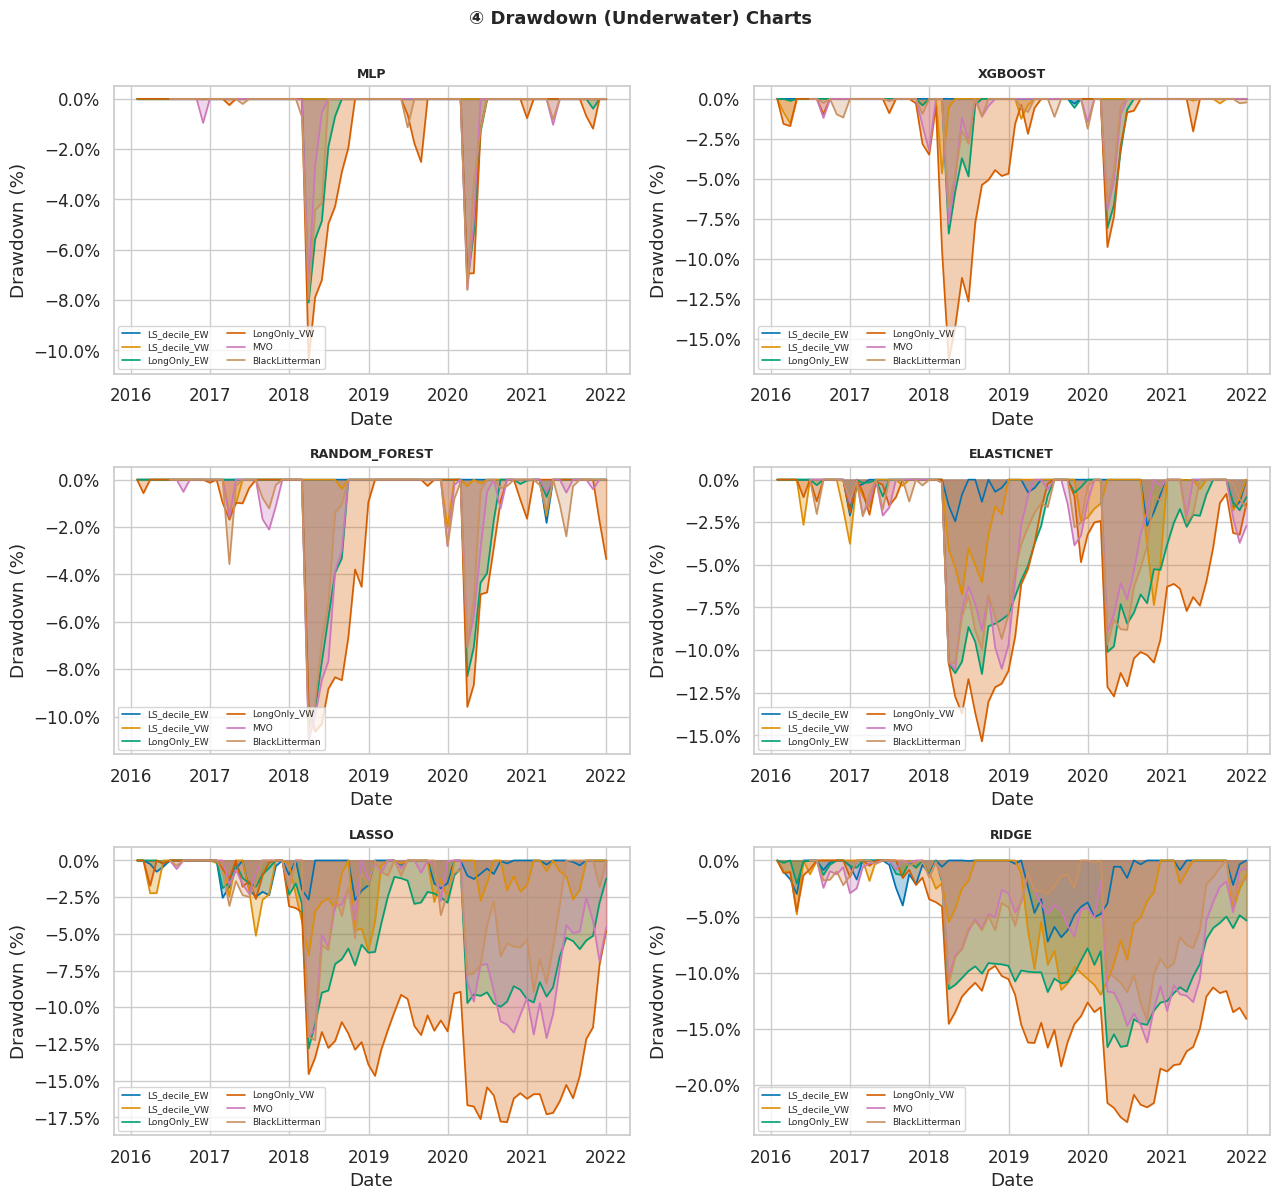

In [7]:
models = _uniq(ports, 0); n = len(models)
ncols = min(2,n); nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4*nrows))
axes = np.array(axes).ravel()
fig.suptitle("④ Drawdown (Underwater) Charts", fontsize=13, fontweight="bold", y=1.0)
for ax, m in zip(axes, models):
    for (mod,s), res in ports.items():
        if mod != m: continue
        dd = _dd(res["ret_net"].dropna())*100
        ax.fill_between(dd.index, -dd.values, 0, alpha=0.30, color=_sc(s))
        ax.plot(dd.index, -dd.values, lw=1.2, color=_sc(s), label=s)
    ax.set_title(m.upper(), fontweight="bold", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel("Drawdown (%)"); ax.set_xlabel("Date")
    ax.legend(fontsize=6.5, ncol=2, loc="lower left")
for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()


## ⑤ Rolling 12-Month Sharpe

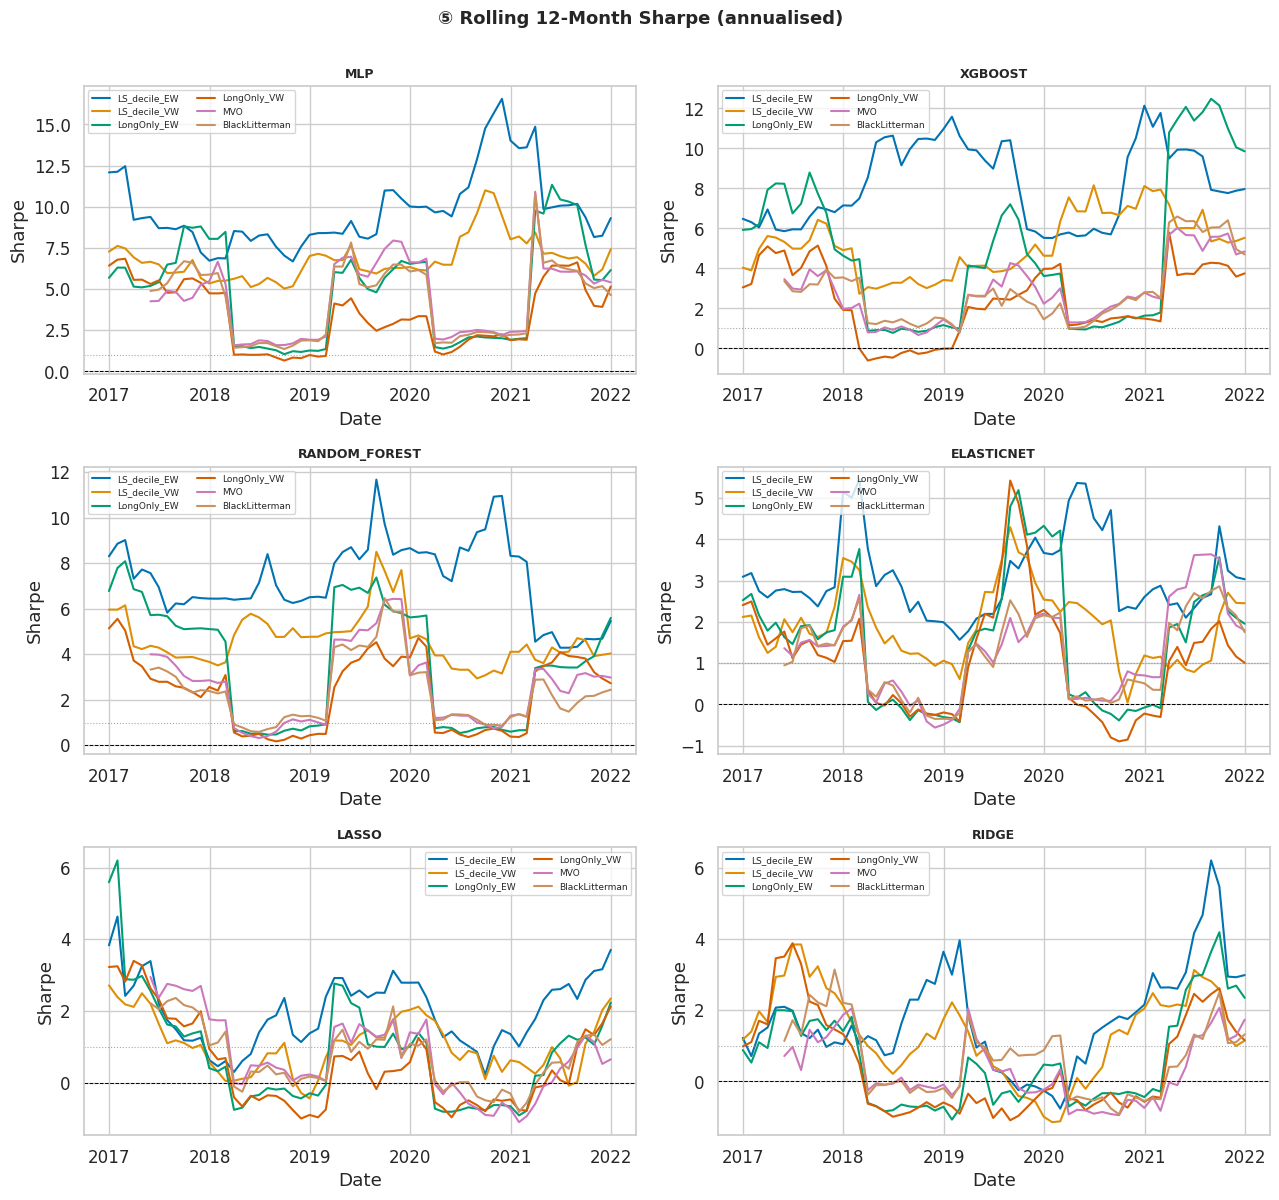

In [8]:
models = _uniq(ports, 0); n = len(models)
ncols = min(2,n); nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4*nrows))
axes = np.array(axes).ravel()
fig.suptitle("⑤ Rolling 12-Month Sharpe (annualised)", fontsize=13, fontweight="bold", y=1.0)
for ax, m in zip(axes, models):
    for (mod,s), res in ports.items():
        if mod != m: continue
        r = res["ret_net"].dropna()
        rs = r.rolling(12).apply(
            lambda x: x.mean()/x.std(ddof=1)*12**0.5 if x.std(ddof=1)>0 else np.nan, raw=True)
        ax.plot(rs.index, rs.values, lw=1.5, color=_sc(s), label=s)
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.axhline(1, color="grey",  lw=0.8, ls=":", alpha=0.7)
    ax.set_title(m.upper(), fontweight="bold", fontsize=9)
    ax.set_ylabel("Sharpe"); ax.set_xlabel("Date")
    ax.legend(fontsize=6.5, ncol=2)
for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()


## ⑥ Decile Bar — Monotonicity Check

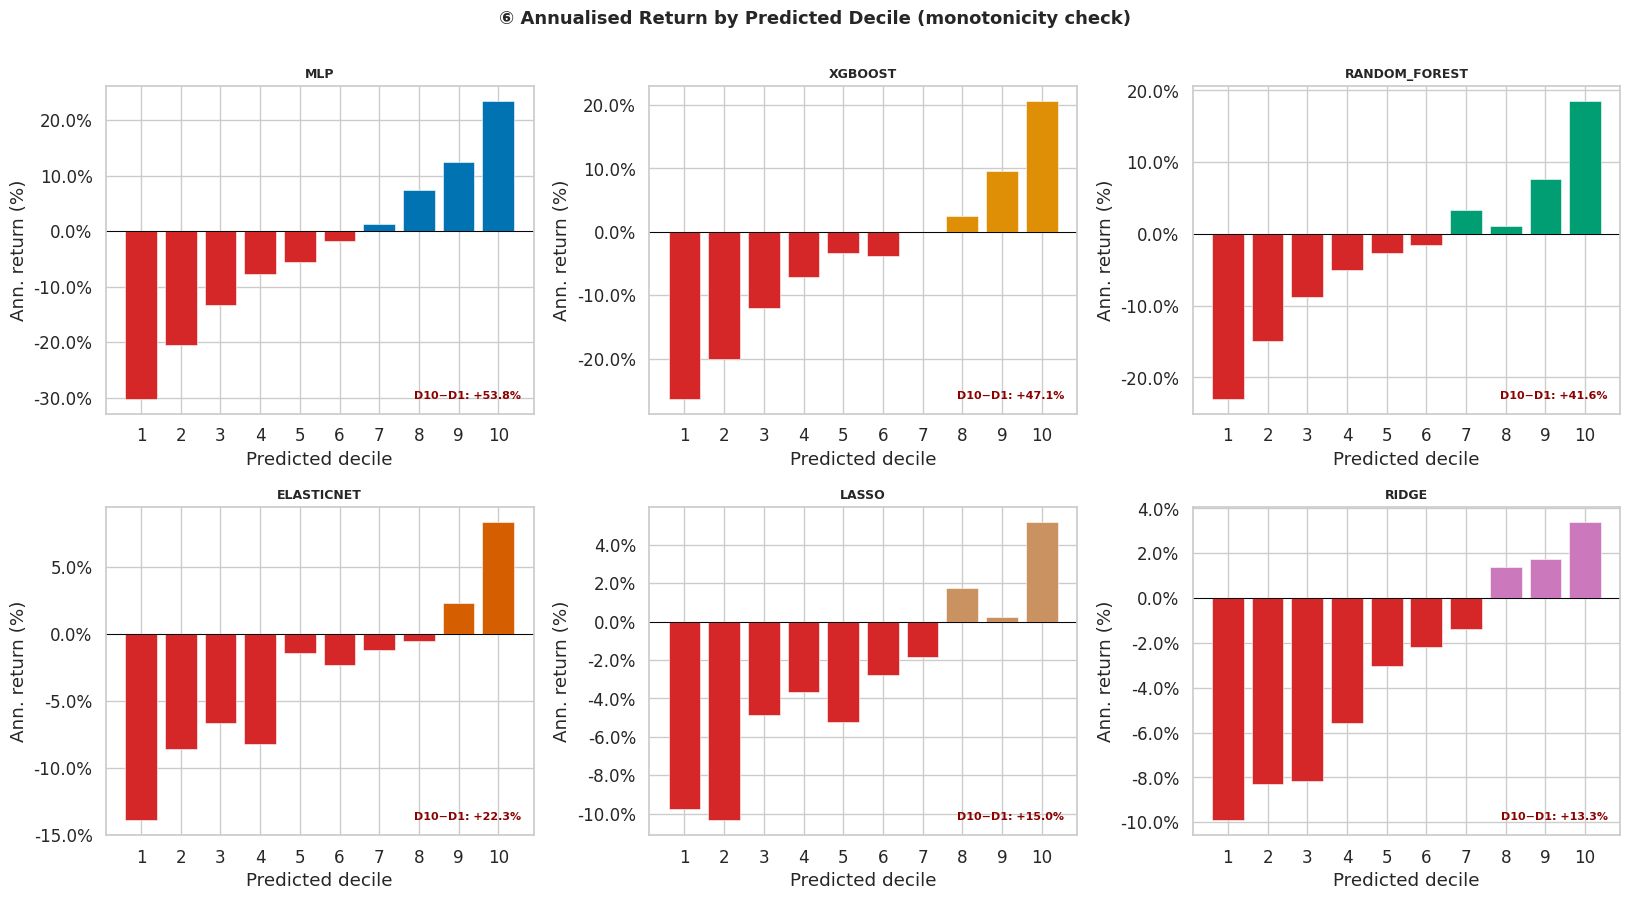

In [9]:
items = list(pred_panels.items()); n = len(items)
ncols = min(3,n); nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows))
axes = np.array(axes).ravel()
fig.suptitle("⑥ Annualised Return by Predicted Decile (monotonicity check)",
             fontsize=13, fontweight="bold", y=1.0)
for ax, (name, panel) in zip(axes, items):
    recs = []
    for d, g in panel.groupby("eom"):
        if len(g) < 10: continue
        g = g.copy()
        g["bkt"] = pd.qcut(g["pred"].rank(method="first"), 10,
                           labels=False, duplicates="drop") + 1
        for b, bg in g.groupby("bkt"):
            recs.append({"bkt":b,
                "ret": float((pd.Series(1/len(bg),index=bg.index)*bg["ret_exc_lead1m"]).sum())})
    if not recs: ax.set_visible(False); continue
    means = pd.DataFrame(recs).groupby("bkt")["ret"].mean() * 12
    cols = ["#d62728" if v<0 else _mc(name) for v in means.values]
    ax.bar(means.index, means.values*100, color=cols, edgecolor="white", lw=0.4)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_title(name.upper(), fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted decile"); ax.set_ylabel("Ann. return (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.set_xticks(range(1,11))
    spread = (means.iloc[-1]-means.iloc[0])*100
    ax.text(0.97,0.04,f"D10−D1: {spread:+.1f}%", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color="darkred", fontweight="bold")
for ax in axes[n:]: ax.set_visible(False)
plt.tight_layout(); plt.show()


## ⑦ Grand Comparison Heatmap

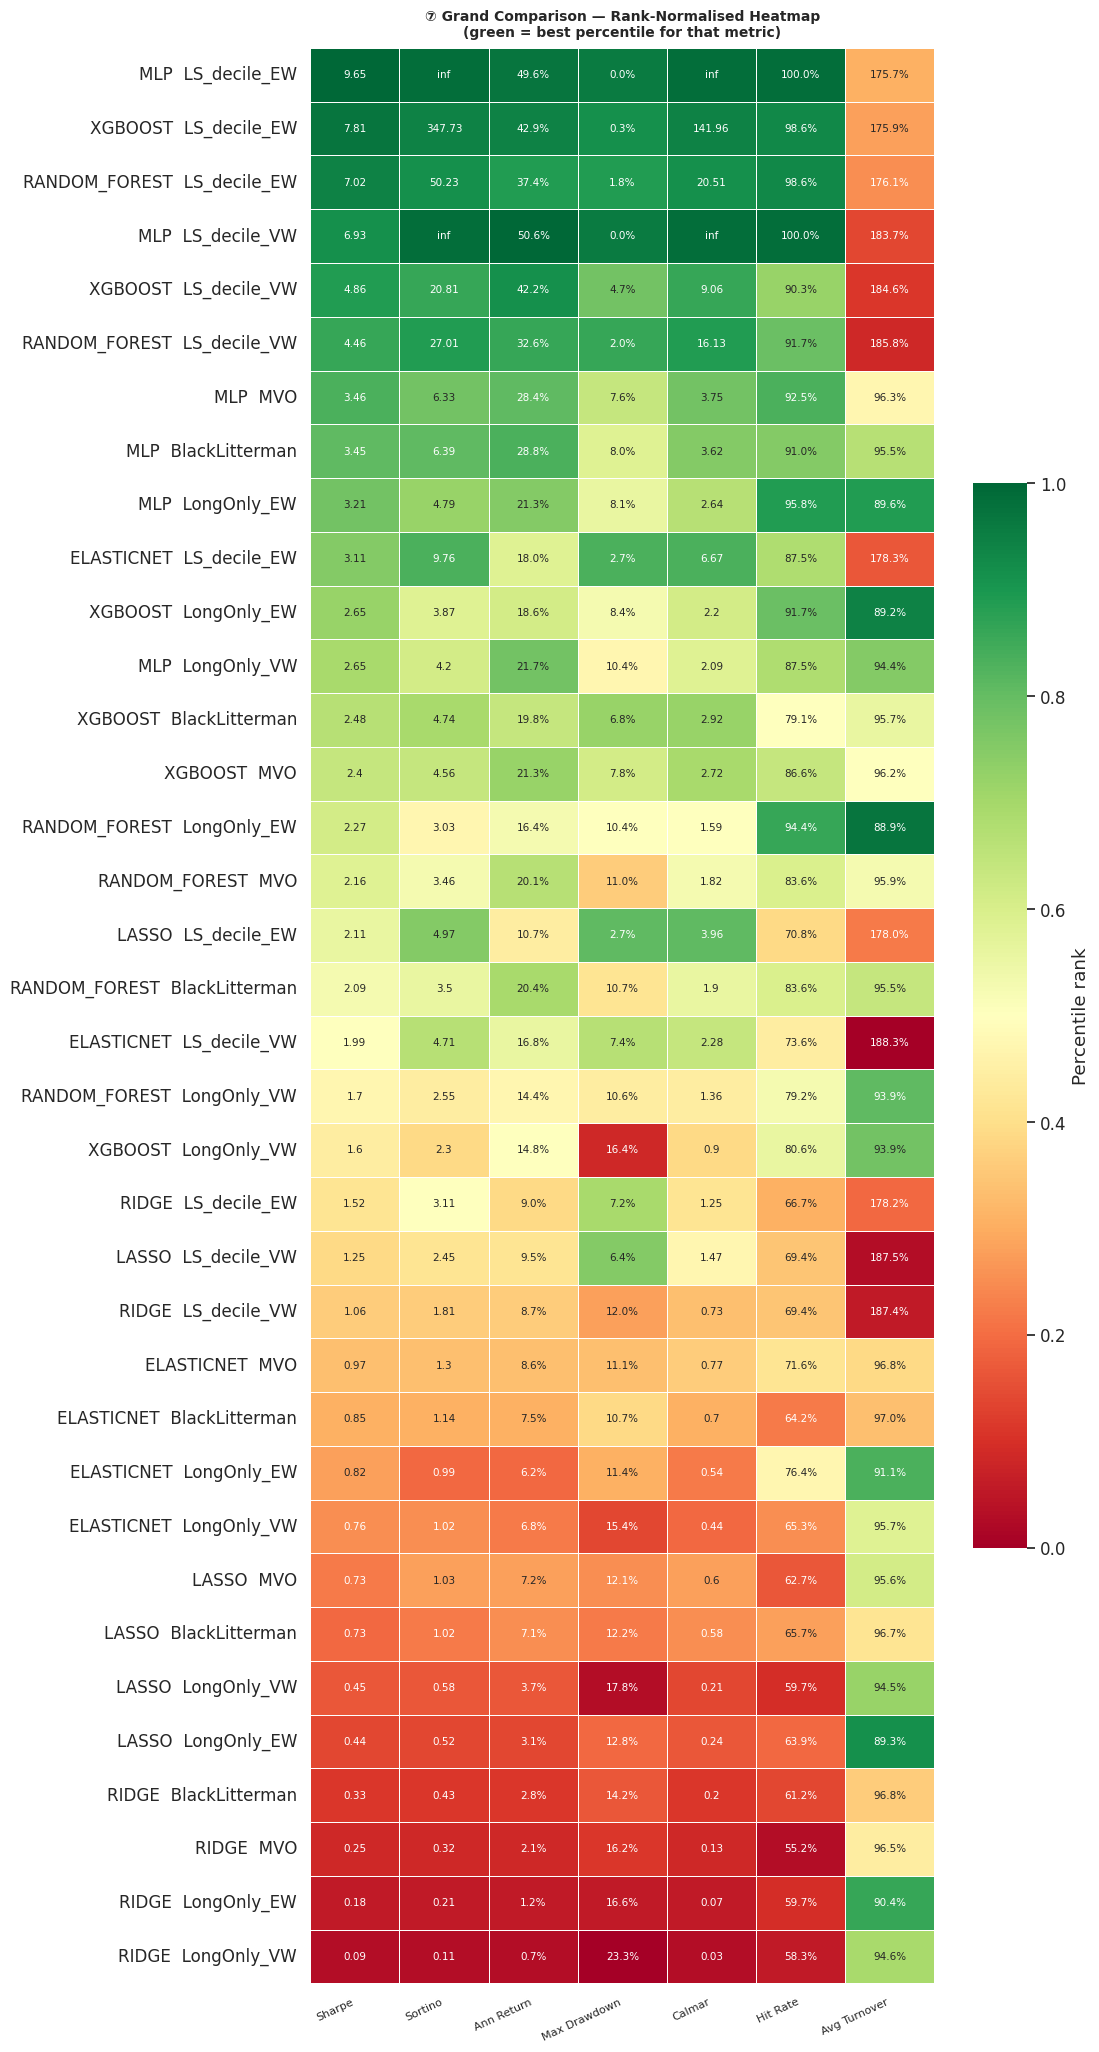

In [10]:
lower = {"max_drawdown","avg_turnover","ann_vol","ann_cost"}
want  = ["sharpe","sortino","ann_return","max_drawdown","calmar","hit_rate","avg_turnover"]
metrics = [c for c in want if c in comp.columns]
df2 = comp.copy()
df2["combo"] = df2["model"].str.upper() + "  " + df2["strategy"]
df2 = df2.set_index("combo")[metrics]
ranked = df2.copy().astype(float)
for c in ranked.columns:
    pr = ranked[c].rank(pct=True)
    ranked[c] = (1-pr) if c in lower else pr
ann = df2.copy().astype(object)
for c in metrics:
    if c in ("max_drawdown","ann_return","hit_rate","avg_turnover"):
        ann[c] = (df2[c].astype(float)*100).round(1).astype(str)+"%"
    elif c in ("sharpe","sortino","calmar"):
        ann[c] = df2[c].astype(float).round(2).astype(str)
    else:
        ann[c] = df2[c].astype(float).round(3).astype(str)
fig, ax = plt.subplots(figsize=(max(10,len(metrics)*1.6), max(8,len(df2)*0.52+2)))
sns.heatmap(ranked, ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
            annot=ann.values, fmt="", linewidths=0.4, linecolor="white",
            annot_kws={"size":7.5},
            cbar_kws={"label":"Percentile rank","shrink":0.55})
ax.set_title("⑦ Grand Comparison — Rank-Normalised Heatmap\n"
             "(green = best percentile for that metric)",
             fontsize=10, fontweight="bold", pad=8)
ax.set_xticklabels([c.replace("_"," ").title() for c in metrics],
                   rotation=25, ha="right", fontsize=8)
ax.set_ylabel("")
plt.tight_layout(); plt.show()


## ⑧ Turnover & Transaction Costs

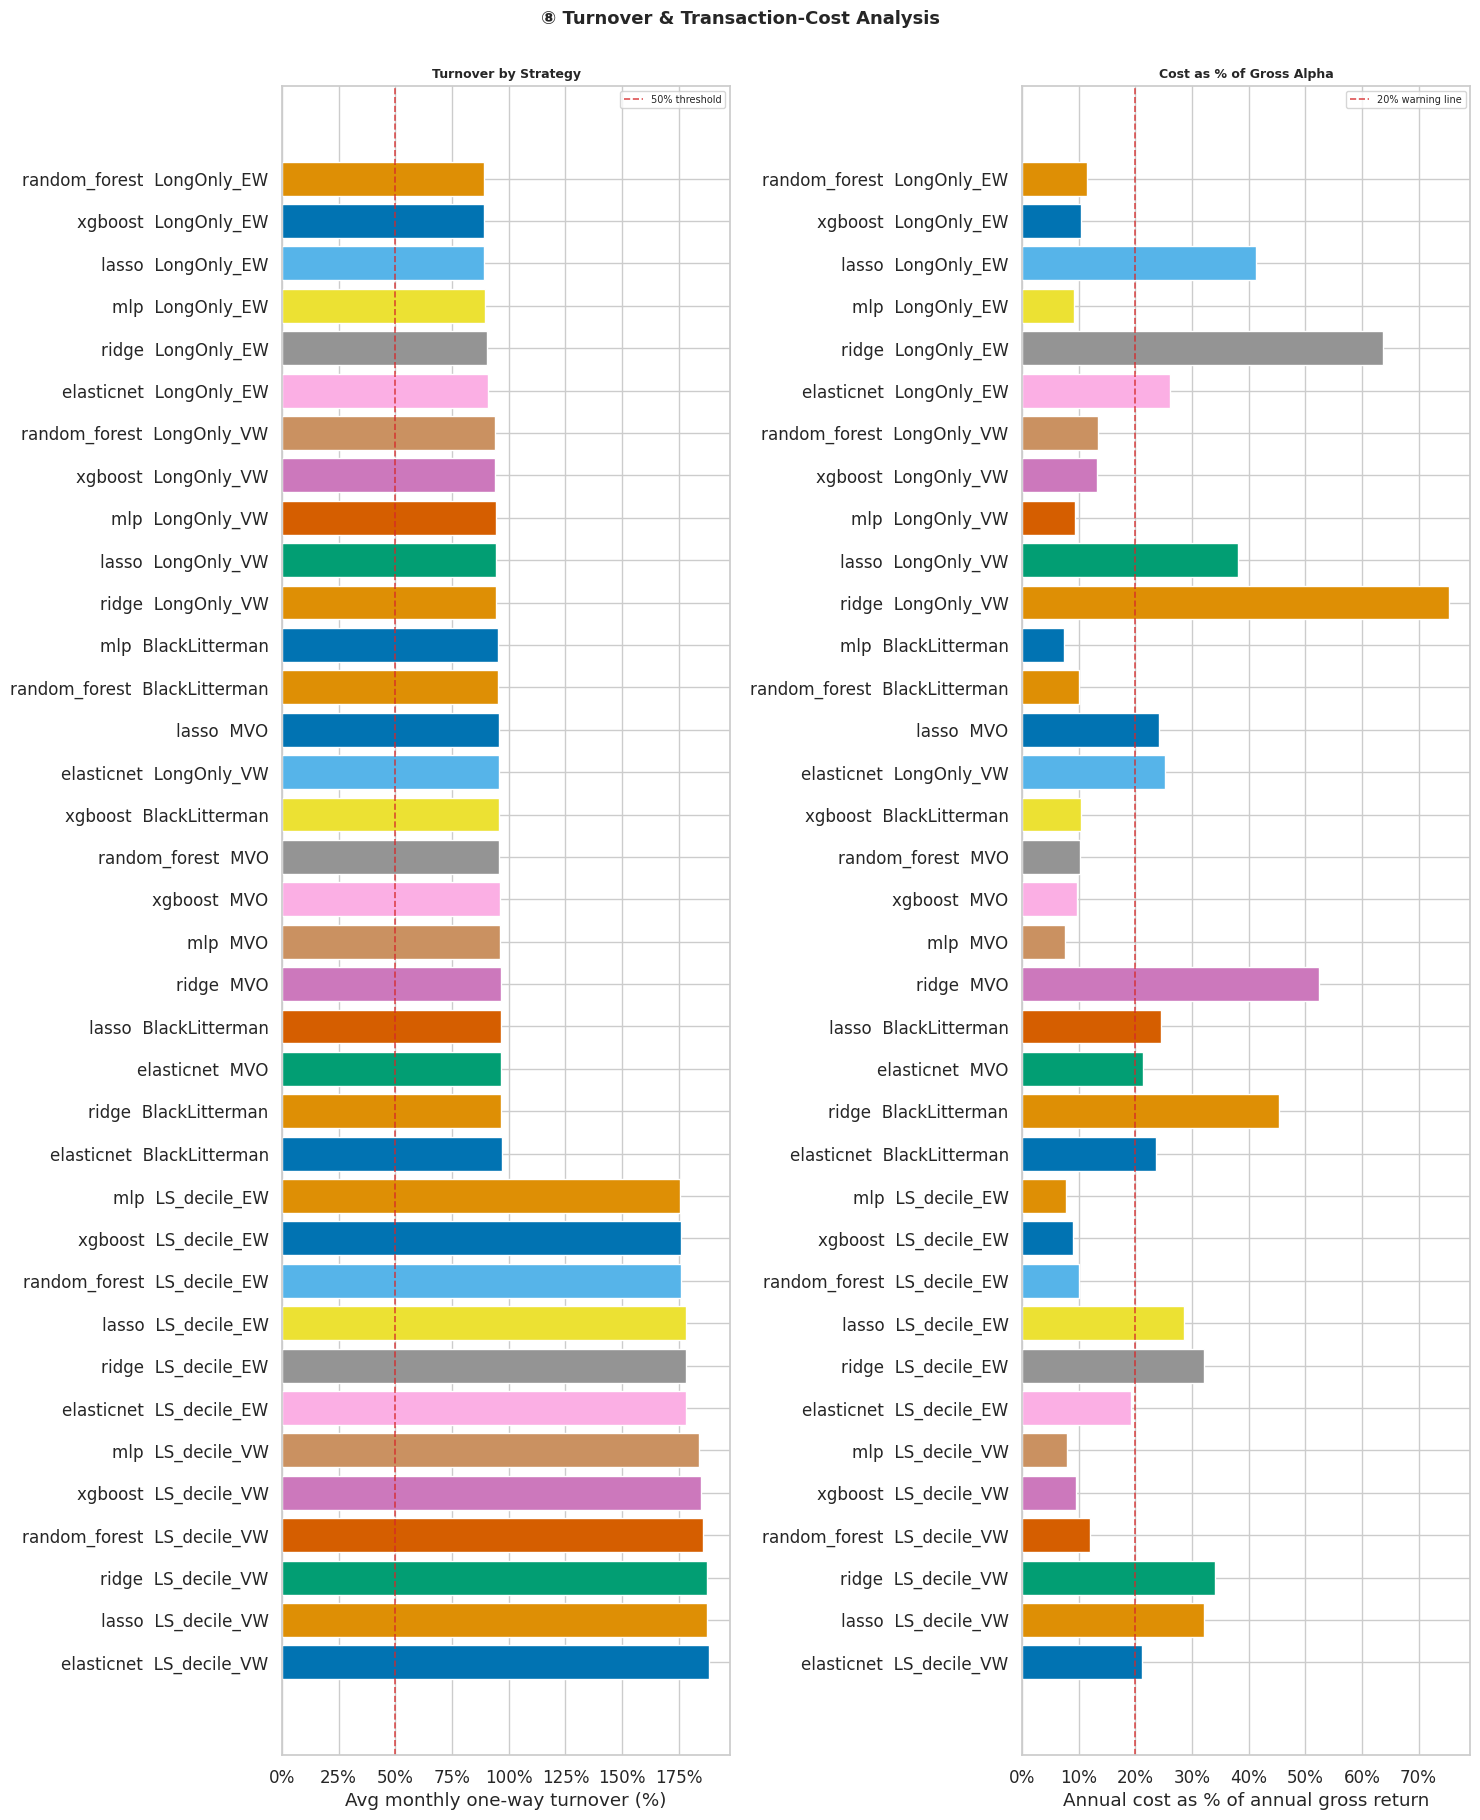

In [11]:
rows = []
for (m,s), res in ports.items():
    gross = res["ret_gross"].mean()*12 if "ret_gross" in res else np.nan
    cost  = res["cost"].mean()*12      if "cost"      in res else 0.0
    to    = res["turnover"].mean()      if "turnover"  in res else np.nan
    rows.append({"combo":f"{m}  {s}","turnover":to,
                 "cost_pct": cost/abs(gross)*100 if (gross and not np.isnan(gross)) else np.nan})
df3 = pd.DataFrame(rows).sort_values("turnover", ascending=False)
colors3 = [PALETTE[i%12] for i in range(len(df3))]
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, max(5, len(df3)*0.45+2)))
fig.suptitle("⑧ Turnover & Transaction-Cost Analysis", fontsize=13, fontweight="bold", y=1.0)
ax1.barh(df3["combo"], df3["turnover"]*100, color=colors3, edgecolor="white")
ax1.set_xlabel("Avg monthly one-way turnover (%)")
ax1.set_title("Turnover by Strategy", fontweight="bold", fontsize=9)
ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
ax1.axvline(50, color="#d62728", lw=1.2, ls="--", alpha=0.8, label="50% threshold")
ax1.legend(fontsize=7)
ax2.barh(df3["combo"], df3["cost_pct"], color=colors3, edgecolor="white")
ax2.set_xlabel("Annual cost as % of annual gross return")
ax2.set_title("Cost as % of Gross Alpha", fontweight="bold", fontsize=9)
ax2.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
ax2.axvline(20, color="#d62728", lw=1.2, ls="--", alpha=0.8, label="20% warning line")
ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()


## ⑨ Return Distributions

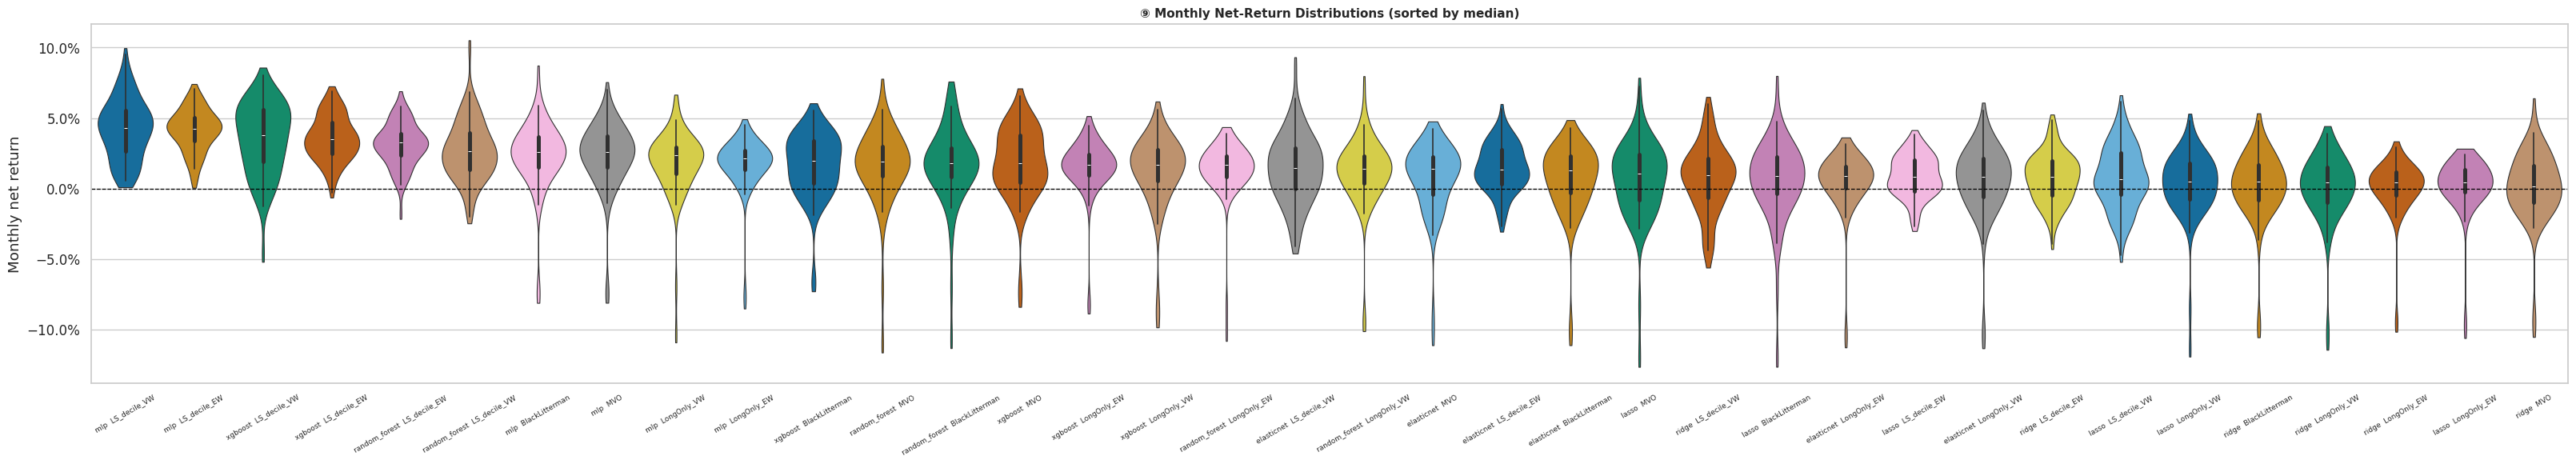

In [12]:
records = []
for (m,s), res in ports.items():
    for v in res["ret_net"].dropna():
        records.append({"combo":f"{m}  {s}","return":v})
df4 = pd.DataFrame(records)
order = df4.groupby("combo")["return"].median().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(max(10,len(order)*0.9), 6))
sns.violinplot(data=df4, x="combo", y="return", order=order, ax=ax,
               inner="box", palette="colorblind", cut=0.5, linewidth=0.8)
ax.axhline(0, color="black", lw=0.9, ls="--")
ax.set_title("⑨ Monthly Net-Return Distributions (sorted by median)",
             fontsize=11, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Monthly net return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", labelsize=6.5, rotation=30)
plt.tight_layout(); plt.show()


## ⑩ Radar Chart — Top-5 Combos

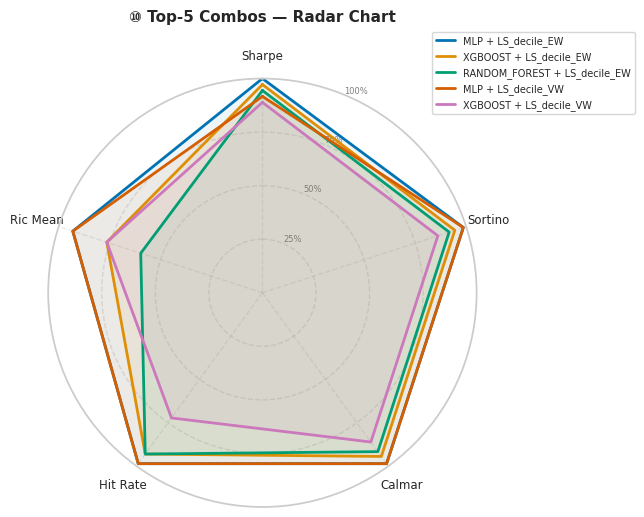

In [13]:
top_n = 5
lower_r = {"max_drawdown","avg_turnover"}
want_r  = ["sharpe","sortino","calmar","hit_rate","ric_mean"]
metrics_r = [c for c in want_r if c in comp.columns]
dfr = comp.head(top_n).copy()
dfr["combo"] = dfr["model"].str.upper()+" + "+dfr["strategy"]
full_r = comp[metrics_r].astype(float)
ranked_r = pd.DataFrame(index=dfr.index, columns=metrics_r, dtype=float)
for c in metrics_r:
    pr = full_r[c].rank(pct=True)
    ranked_r[c] = (1-pr.iloc[:top_n].values if c in lower_r else pr.iloc[:top_n].values)
angles = np.linspace(0,2*np.pi,len(metrics_r),endpoint=False).tolist()+[0]
colors_r = PALETTE[:top_n]
fig, ax = plt.subplots(figsize=(7,7), subplot_kw={"polar":True})
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace("_"," ").title() for m in metrics_r], fontsize=8.5)
ax.set_ylim(0,1); ax.set_yticks([0.25,0.5,0.75,1.0])
ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=6, color="grey")
ax.yaxis.grid(True,ls="--",alpha=0.5); ax.xaxis.grid(True,ls="--",alpha=0.4)
for i,(_,row) in enumerate(ranked_r.iterrows()):
    vals = row.tolist()+[row.iloc[0]]
    ax.plot(angles,vals,lw=2,color=colors_r[i],label=dfr["combo"].iloc[i])
    ax.fill(angles,vals,alpha=0.07,color=colors_r[i])
ax.set_title(f"⑩ Top-{top_n} Combos — Radar Chart", pad=20, fontsize=11, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.38,1.12), fontsize=7)
plt.tight_layout(); plt.show()


## ⑪ Winner — Monthly Returns Calendar Heatmap

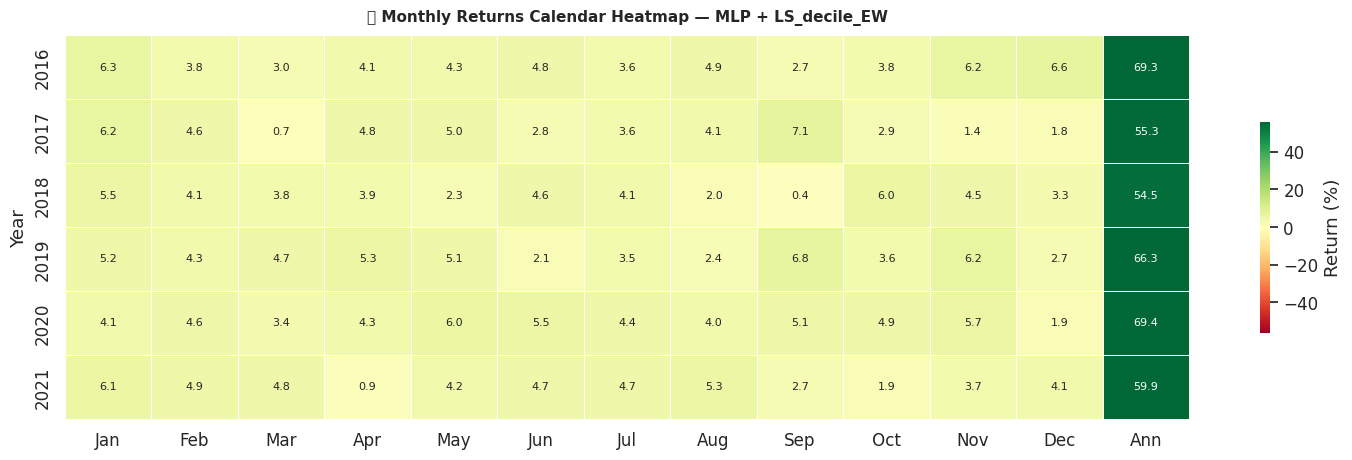

In [14]:
bk = best_key
if bk and bk in ports:
    r_win = ports[bk]["ret_net"]
    t_win = f"{bk[0].upper()} + {bk[1]}"
else:
    k = next(iter(ports)); r_win = ports[k]["ret_net"]; t_win = str(k)

r_cal = r_win.dropna().copy()
r_cal.index = pd.to_datetime(r_cal.index)
tmp = r_cal.rename("ret").to_frame()
tmp["year"] = tmp.index.year; tmp["month"] = tmp.index.month
pivot = tmp.pivot_table(values="ret", index="year", columns="month")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"][:len(pivot.columns)]
annual = r_cal.groupby(r_cal.index.year).apply(lambda x: (1+x).prod()-1)
pivot["Ann"] = annual.values[:len(pivot)]
vmax = np.nanpercentile(np.abs(pivot.values), 95)
fig, ax = plt.subplots(figsize=(15, max(4, len(pivot)*0.55+1.5)))
sns.heatmap(pivot*100, ax=ax, cmap="RdYlGn", center=0,
            vmin=-vmax*100, vmax=vmax*100,
            annot=True, fmt=".1f", linewidths=0.4, linecolor="white",
            annot_kws={"size":8},
            cbar_kws={"label":"Return (%)","shrink":0.55})
ax.set_title(f"⑪ Monthly Returns Calendar Heatmap — {t_win}",
             fontsize=11, fontweight="bold", pad=10)
ax.set_xlabel(""); ax.set_ylabel("Year"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()


## 📋 Grand Comparison Table

In [15]:
from IPython.display import display
styled = (comp.round(3)
              .style
              .background_gradient(subset=["sharpe","sortino","ann_return"],
                                   cmap="Greens")
              .background_gradient(subset=["max_drawdown","avg_turnover"],
                                   cmap="Reds_r")
              .format({"ann_return":"{:.1%}","ann_vol":"{:.1%}",
                       "max_drawdown":"{:.1%}","avg_turnover":"{:.0%}",
                       "hit_rate":"{:.1%}","sharpe":"{:.2f}",
                       "sortino":"{:.2f}","calmar":"{:.2f}",
                       "ric_mean":"{:.4f}","ic_t_stat":"{:.2f}"})
              .set_caption("Grand Comparison — all model × strategy combinations")
              .set_table_styles([{"selector":"caption",
                                  "props":[("font-size","13px"),
                                           ("font-weight","bold"),
                                           ("text-align","left")]}]))
display(styled)


,model,strategy,sharpe,sortino,ann_return,ann_vol,max_drawdown,calmar,hit_rate,avg_turnover,ann_cost,n_months,ric_mean,ic_ir,ic_t_stat,oos_r2
0,mlp,LS_decile_EW,9.65,inf,49.6%,5.1%,0.0%,inf,100.0%,176%,0.042000,72,0.2020,3.548000,30.10,-246.904000
1,xgboost,LS_decile_EW,7.81,347.73,42.9%,5.5%,0.3%,141.96,98.6%,176%,0.042000,72,0.1710,3.270000,27.74,-243.072000
2,random_forest,LS_decile_EW,7.02,50.23,37.4%,5.3%,1.8%,20.50,98.6%,176%,0.042000,72,0.1430,2.899000,24.60,-251.246000
3,mlp,LS_decile_VW,6.93,inf,50.6%,7.3%,0.0%,inf,100.0%,184%,0.044000,72,0.2020,3.548000,30.10,-246.904000
4,xgboost,LS_decile_VW,4.86,20.81,42.2%,8.7%,4.7%,9.06,90.3%,185%,0.044000,72,0.1710,3.270000,27.74,-243.072000
5,random_forest,LS_decile_VW,4.46,27.01,32.6%,7.3%,2.0%,16.13,91.7%,186%,0.045000,72,0.1430,2.899000,24.60,-251.246000
6,mlp,MVO,3.46,6.33,28.4%,8.2%,7.6%,3.75,92.5%,96%,0.023000,67,0.2020,3.548000,30.10,-246.904000
7,mlp,BlackLitterman,3.45,6.39,28.8%,8.3%,8.0%,3.62,91.0%,96%,0.023000,67,0.2020,3.548000,30.10,-246.904000
8,mlp,LongOnly_EW,3.21,4.79,21.3%,6.6%,8.1%,2.64,95.8%,90%,0.022000,72,0.2020,3.548000,30.10,-246.904000
9,elasticnet,LS_decile_EW,3.11,9.76,18.0%,5.8%,2.7%,6.67,87.5%,178%,0.043000,72,0.0800,1.436000,12.18,-257.409000
